# AstroKit simqso Demo: SDSS-like Quasar Mock Catalog

这个 notebook 演示如何使用 `astrokit.simqso` 生成红移 `0 < z < 4` 的类星体模拟光谱，加入 IGM HI 吸收，计算 SDSS `ugriz` 测光并导出一个 SDSS-like 模拟类星体星表。

最后会读取本地的 SDSS DR16Q 星表：

`../data/example_data_simqso/DR16Q_v4.fits`

并用关键颜色 `u-g`、`g-r`、`r-i`、`i-z` 的颜色-颜色图对比模拟类星体与真实类星体的颜色分布。

## 1. Imports and Paths

如果直接从 `demo/notebooks` 启动 notebook，下面的路径设置会把本地 `astrokit` 源码树加入 `sys.path`。如果你已经在当前环境安装了 AstroKit，这个单元也可以安全运行。

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
from astropy.table import Table
from scipy.stats import ks_2samp

# Make the local source tree importable when running this notebook from demo/notebooks.
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "astrokit" / "__init__.py").exists():
        sys.path.insert(0, str(parent))
        REPO_ROOT = parent
        break
else:
    raise RuntimeError("Could not find the AstroKit source tree from the current directory.")

from astrokit.simqso import sqbase, sqgrids, sqmodels, sqphoto, sqrun

DATA_DIR = REPO_ROOT / "demo" / "data" / "example_data_simqso"
DR16Q_PATH = DATA_DIR / "DR16Q_v4.fits"
OUTPUT_DIR = DATA_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MOCK_CATALOG_PATH = OUTPUT_DIR / "astrokit_simqso_sdss_mock_z0_4.fits"

print(f"AstroKit root: {REPO_ROOT}")
print(f"DR16Q catalog: {DR16Q_PATH}")
print(f"Mock catalog output: {MOCK_CATALOG_PATH}")

AstroKit root: /Users/rui/Packages/astrokit
DR16Q catalog: /Users/rui/Packages/astrokit/demo/data/example_data_simqso/DR16Q_v4.fits
Mock catalog output: /Users/rui/Packages/astrokit/demo/data/example_data_simqso/output/astrokit_simqso_sdss_mock_z0_4.fits


## 2. Configure the Simulation

这里用一个简单的 SDSS-like 选择函数生成目标红移和近似 `i` 波段星等，然后通过连续谱 K-correction 换算到 `M1450`。这不是完整的类星体光度函数建模，目的是让 demo 的模拟样本在亮度范围上接近 DR16Q 中用于颜色对比的对象。

默认样本数保持在交互式运行比较舒服的规模；如果想看更平滑的颜色密度，可以增大 `N_SIM` 和 `N_IGM_SIGHTLINES`。

In [10]:
RANDOM_SEED = 20260721
N_SIM = 2000
N_IGM_SIGHTLINES = 300

Z_MIN, Z_MAX = 0.05, 4.0
I_MAG_RANGE = (17.2, 21.8)
WAVE_RANGE = (3000.0, 11000.0)  # Angstrom, enough for SDSS ugriz synthetic photometry
SPEC_R = 600  # fixed resolving power for the log-lambda grid

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
rng = np.random.default_rng(RANDOM_SEED)

# Uniform-in-z sample for a transparent demo. Replace this with a QLF sampler if needed.
z_sim = rng.uniform(Z_MIN, Z_MAX, N_SIM)

# Draw approximate SDSS i-band target magnitudes, then convert to M1450.
i_target = rng.uniform(*I_MAG_RANGE, N_SIM)
kcorr_i_to_1450 = sqbase.ContinuumKCorr("SDSS-i", 1450.0)
m1450_sim = i_target - cosmo.distmod(z_sim).value - kcorr_i_to_1450(i_target, z_sim)
m1450_sim = np.clip(m1450_sim, -30.5, -20.0)

wave = sqbase.fixed_R_dispersion(*WAVE_RANGE, SPEC_R)

print(f"N_SIM = {N_SIM}")
print(f"redshift range = {z_sim.min():.3f} - {z_sim.max():.3f}")
print(f"M1450 range = {m1450_sim.min():.2f} - {m1450_sim.max():.2f}")
print(f"wavelength grid = {wave.size} pixels from {wave[0]:.0f} to {wave[-1]:.0f} Angstrom")

N_SIM = 2000
redshift range = 0.050 - 3.997
M1450 range = -28.77 - -20.00
wavelength grid = 781 pixels from 3000 to 11008 Angstrom


## 3. Simulate Quasar Spectra with IGM Absorption

`simqso` 的 IGM transmission grid 会沿同一 sightline 按红移递增推进，因此这里使用 `buildSpectraBySightLine`。这和 `qsoSimulation` 内部在启用 IGM 时采用的路径一致。

In [11]:
np.random.seed(RANDOM_SEED)

qso_grid = sqgrids.QsoSimPoints(
    [
        sqgrids.AbsMagVar(sqgrids.FixedSampler(m1450_sim), restWave=1450.0),
        sqgrids.RedshiftVar(sqgrids.FixedSampler(z_sim)),
    ],
    cosmo=cosmo,
    units="luminosity",
)

# Load SDSS Legacy ugriz bandpasses and observational photometric error model.
qso_grid.loadPhotoMap([("SDSS", "Legacy")])

# BOSS DR9-like continuum, emission-line, Fe-template, and IGM absorption variables.
model_vars = sqmodels.get_BossDr9_model_vars(
    qso_grid,
    wave,
    nSightLines=N_IGM_SIGHTLINES,
    forestseed=RANDOM_SEED + 1,
    verbose=1,
)
qso_grid.addVars(model_vars)

# Build spectra and synthetic SDSS photometry. The returned spectra are f_lambda.
qso_grid, spectra = sqrun.buildSpectraBySightLine(
    wave,
    qso_grid,
    maxIter=1,
    saveSpectra=True,
    verbose=1,
)

# Add observed SDSS-like photometry by perturbing synthetic fluxes with the built-in SDSS error model.
obs_photo = sqphoto.calcObsPhot(qso_grid.synFlux, qso_grid.photoMap, seed=RANDOM_SEED + 2)
qso_grid.addData(obs_photo)

print(f"Simulated objects: {qso_grid.nObj}")
print(f"Spectra array: {spectra.shape}")
print("Photometric bands:", qso_grid.photoBands)

Generating 300 sightlines
simulating  2000  quasar spectra
units are  luminosity
max number iterations:  1
processing  4  obj in group  0
Simulated objects: 2000
Spectra array: (2000, 781)
Photometric bands: ['SDSS-Legacy-u', 'SDSS-Legacy-g', 'SDSS-Legacy-r', 'SDSS-Legacy-i', 'SDSS-Legacy-z']


### Inspect a Few Simulated Spectra

下面随机选几个不同红移的模拟光谱。高红移对象在 Lyα 蓝端会出现明显的 IGM 吸收压低。

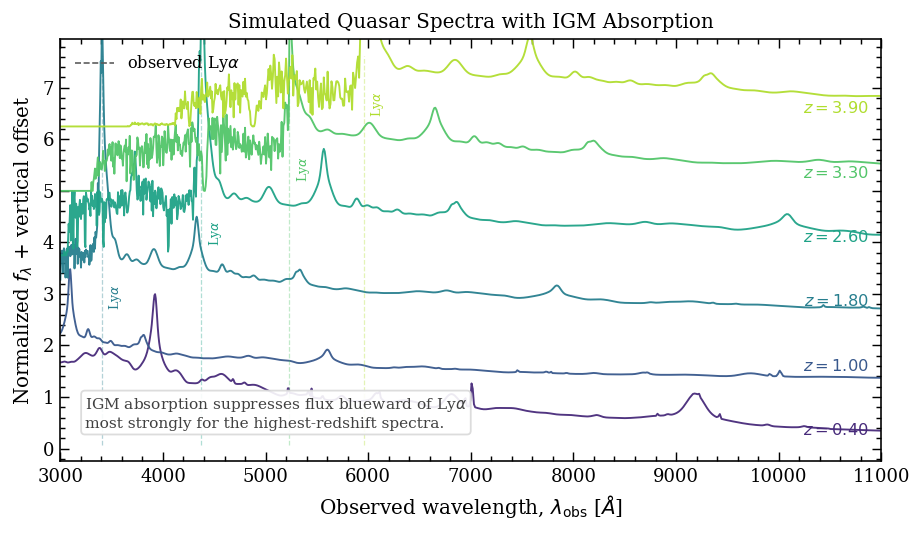

In [18]:
from matplotlib import cm
from matplotlib.lines import Line2D

# Choose representative spectra across redshift, then stack normalized spectra vertically.
z_targets = np.array([0.4, 1.0, 1.8, 2.6, 3.3, 3.9])
example_idx = np.array([np.argmin(np.abs(np.asarray(qso_grid.z) - z0)) for z0 in z_targets])
example_idx = np.unique(example_idx)
example_idx = example_idx[np.argsort(qso_grid.z[example_idx])]

lya_rest = 1215.67
norm_window = (1450.0, 1700.0)  # rest-frame continuum window used only for display normalization
vertical_step = 1.25
colors = cm.viridis(np.linspace(0.12, 0.88, len(example_idx)))

with plt.rc_context(
    {
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "font.family": "serif",
        "font.size": 10,
        "axes.linewidth": 0.9,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "legend.frameon": False,
    }
):
    fig, ax = plt.subplots(figsize=(7.2, 4.2))

    for row, (idx, color) in enumerate(zip(example_idx, colors)):
        z = float(qso_grid.z[idx])
        flux = np.asarray(spectra[idx], dtype=float) * 1e17
        rest_wave = wave / (1.0 + z)
        norm_mask = (rest_wave >= norm_window[0]) & (rest_wave <= norm_window[1]) & np.isfinite(flux)
        norm = np.nanmedian(flux[norm_mask]) if np.any(norm_mask) else np.nanmedian(flux[np.isfinite(flux)])
        norm = norm if np.isfinite(norm) and norm > 0 else 1.0
        y = flux / norm + row * vertical_step

        ax.plot(wave, y, color=color, lw=1.05, alpha=0.95)

        # Mark the observed Ly-alpha wavelength; absorption blueward of this line grows at high z.
        lya_obs = lya_rest * (1.0 + z)
        if wave.min() < lya_obs < wave.max():
            ax.axvline(lya_obs, ymin=0.04, ymax=0.96, color=color, lw=0.7, ls="--", alpha=0.35)
            ax.text(lya_obs + 55, row * vertical_step + 0.18, r"Ly$\alpha$", color=color, fontsize=7, rotation=90, va="bottom")

        ax.text(
            0.985,
            row * vertical_step + 0.18,
            rf"$z={z:.2f}$",
            transform=ax.get_yaxis_transform(),
            color=color,
            fontsize=9,
            ha="right",
            va="bottom",
        )

    ax.set_xlim(3000, 11000)
    ax.set_ylim(-0.25, vertical_step * (len(example_idx) - 1) + 1.7)
    ax.set_xlabel(r"Observed wavelength, $\lambda_{\rm obs}$ [$\AA$]")
    ax.set_ylabel(r"Normalized $f_\lambda$ + vertical offset")
    ax.set_title(r"Simulated Quasar Spectra with IGM Absorption")
    ax.minorticks_on()
    ax.tick_params(which="both", width=0.8)
    ax.tick_params(which="major", length=5)
    ax.tick_params(which="minor", length=2.5)

    guide = Line2D([0], [0], color="0.35", lw=0.9, ls="--", label=r"observed Ly$\alpha$")
    ax.legend(handles=[guide], loc="upper left", fontsize=9, handlelength=2.4)

    ax.text(
        0.03,
        0.08,
        "IGM absorption suppresses flux blueward of Ly$\\alpha$\nmost strongly for the highest-redshift spectra.",
        transform=ax.transAxes,
        fontsize=8.5,
        color="0.25",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.85", alpha=0.9),
    )

    plt.tight_layout()
    plt.show()

## 4. Build and Save an SDSS-like Mock Catalog

输出星表保留 DR16Q 风格的二维 `PSFMAG` / `PSFMAGERR` 列，同时额外展开每个波段的标量列，方便后续筛选和作图。

In [13]:
band_labels = [band.split("-")[-1] for band in qso_grid.photoBands]
obs_mag = np.asarray(qso_grid.obsMag)
obs_mag_err = np.asarray(qso_grid.obsMagErr)
syn_mag = np.asarray(qso_grid.synMag)
syn_flux = np.asarray(qso_grid.synFlux)

mock_catalog = Table()
mock_catalog["OBJID"] = np.arange(qso_grid.nObj, dtype=np.int64)
mock_catalog["RA"] = rng.uniform(0.0, 360.0, qso_grid.nObj)
mock_catalog["DEC"] = np.degrees(np.arcsin(rng.uniform(np.sin(np.radians(-5.0)), np.sin(np.radians(65.0)), qso_grid.nObj)))
mock_catalog["Z"] = np.asarray(qso_grid.z)
mock_catalog["M1450"] = np.asarray(qso_grid.absMag)
mock_catalog["TARGET_I"] = i_target
mock_catalog["PSFMAG"] = obs_mag
mock_catalog["PSFMAGERR"] = obs_mag_err
mock_catalog["SYNMAG"] = syn_mag
mock_catalog["SYNFLUX_NMGY"] = syn_flux

for j, band in enumerate(band_labels):
    upper = band.upper()
    mock_catalog[f"PSFMAG_{upper}"] = obs_mag[:, j]
    mock_catalog[f"PSFMAGERR_{upper}"] = obs_mag_err[:, j]
    mock_catalog[f"SYNMAG_{upper}"] = syn_mag[:, j]
    mock_catalog[f"SYNFLUX_{upper}_NMGY"] = syn_flux[:, j]

mock_catalog.meta["COMMENT"] = "AstroKit simqso SDSS-like quasar mock catalog, z=0-4, with IGM absorption."
mock_catalog.write(MOCK_CATALOG_PATH, overwrite=True)

print(f"Wrote {len(mock_catalog)} rows to {MOCK_CATALOG_PATH}")
mock_catalog[:5]

Wrote 2000 rows to /Users/rui/Packages/astrokit/demo/data/example_data_simqso/output/astrokit_simqso_sdss_mock_z0_4.fits


OBJID,RA,DEC,Z,M1450,TARGET_I,PSFMAG,PSFMAGERR,SYNMAG,SYNFLUX_NMGY,PSFMAG_U,PSFMAGERR_U,SYNMAG_U,SYNFLUX_U_NMGY,PSFMAG_G,PSFMAGERR_G,SYNMAG_G,SYNFLUX_G_NMGY,PSFMAG_R,PSFMAGERR_R,SYNMAG_R,SYNFLUX_R_NMGY,PSFMAG_I,PSFMAGERR_I,SYNMAG_I,SYNFLUX_I_NMGY,PSFMAG_Z,PSFMAGERR_Z,SYNMAG_Z,SYNFLUX_Z_NMGY
int64,float64,float64,float32,float32,float64,float32[5],float32[5],float32[5],float32[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
0,248.80150035737267,47.76502674684564,2.8188746,-27.427517,17.818224328202973,18.792519 .. 17.714376,0.023739813 .. 0.02193496,18.766338 .. 17.707539,31.150496 .. 82.60084,18.792519,0.023739813,18.766338,31.150496,17.916561,0.016934922,17.909811,68.56077,17.73391,0.016402865,17.763763,78.43224,17.723505,0.016745972,17.743994,79.873436,17.714376,0.02193496,17.707539,82.60084
1,265.46532922524443,44.30488018937138,1.0691096,-23.69604,19.298917017819765,19.485132 .. 19.125393,0.030824266 .. 0.04929658,19.478878 .. 19.08864,16.16028 .. 23.149612,19.485132,0.030824266,19.478878,16.16028,19.369457,0.018967466,19.382616,17.658499,19.153982,0.01935635,19.151478,21.847874,19.116829,0.019810967,19.158613,21.704758,19.125393,0.04929658,19.08864,23.149612
2,104.13768894635541,28.37926819724709,1.7276274,-23.031992,21.100353678381005,21.118284 .. 21.00333,0.06479507 .. 0.21548823,21.101566 .. 20.953878,3.6255474 .. 4.153829,21.118284,0.06479507,21.101566,3.6255474,21.10455,0.03604072,21.104223,3.6166825,21.172659,0.04575232,21.130379,3.5306003,20.90583,0.07332419,20.910206,4.3243184,21.00333,0.21548823,20.953878,4.153829
3,91.30147912218554,49.134361596392665,2.2332888,-26.4779,18.244884985074545,18.652136 .. 17.951439,0.023574669 .. 0.023578387,18.663607 .. 17.94043,34.241844 .. 66.65428,18.652136,0.023574669,18.663607,34.241844,18.280106,0.017213928,18.268501,49.271935,18.190786,0.017089987,18.200619,52.450813,18.070198,0.016927196,18.112467,56.88706,17.951439,0.023578387,17.94043,66.65428
4,251.23059403633198,57.14402889702198,1.9023848,-26.693672,17.661940989940778,17.715141 .. 17.114044,0.019249137 .. 0.019310674,17.72377 .. 17.08443,81.37516 .. 146.63158,17.715141,0.019249137,17.72377,81.37516,17.671482,0.016832901,17.662615,86.09025,17.493061,0.016444342,17.510695,99.01991,17.143496,0.016447412,17.160788,136.67383,17.114044,0.019310674,17.08443,146.63158


## 5. Load DR16Q and Compute Key SDSS Colors

DR16Q 的 `PSFMAG` 列顺序为 SDSS `u, g, r, i, z`。这里筛选 `0 < z < 4`、五个波段星等有限且与模拟样本 `i` 波段范围接近的真实类星体。

In [14]:
def sdss_colors(psfmag):
    """Return key SDSS colors from an array ordered as u, g, r, i, z."""
    psfmag = np.asarray(psfmag)
    return {
        "u-g": psfmag[:, 0] - psfmag[:, 1],
        "g-r": psfmag[:, 1] - psfmag[:, 2],
        "r-i": psfmag[:, 2] - psfmag[:, 3],
        "i-z": psfmag[:, 3] - psfmag[:, 4],
    }

with fits.open(DR16Q_PATH, memmap=True) as hdul:
    dr16_data = hdul[1].data
    z_real_all = np.asarray(dr16_data["Z"], dtype=float)
    psfmag_real_all = np.asarray(dr16_data["PSFMAG"], dtype=float)

real_mask = (
    np.isfinite(z_real_all)
    & (z_real_all >= Z_MIN)
    & (z_real_all <= Z_MAX)
    & np.all(np.isfinite(psfmag_real_all), axis=1)
    & np.all((psfmag_real_all > 0.0) & (psfmag_real_all < 30.0), axis=1)
    & (psfmag_real_all[:, 3] >= I_MAG_RANGE[0])
    & (psfmag_real_all[:, 3] <= I_MAG_RANGE[1])
)

z_real = z_real_all[real_mask]
psfmag_real = psfmag_real_all[real_mask]

# Down-sample only for plotting speed. Statistics below use the same plotting sample for consistency.
N_REAL_PLOT = min(50000, len(z_real))
real_plot_idx = rng.choice(len(z_real), size=N_REAL_PLOT, replace=False)
z_real_plot = z_real[real_plot_idx]
psfmag_real_plot = psfmag_real[real_plot_idx]

sim_mask = (
    np.all(np.isfinite(obs_mag), axis=1)
    & np.all((obs_mag > 0.0) & (obs_mag < 30.0), axis=1)
    & (obs_mag[:, 3] >= I_MAG_RANGE[0])
    & (obs_mag[:, 3] <= I_MAG_RANGE[1])
)
psfmag_sim = obs_mag[sim_mask]
z_sim_plot = np.asarray(qso_grid.z)[sim_mask]

colors_real = sdss_colors(psfmag_real_plot)
colors_sim = sdss_colors(psfmag_sim)

print(f"DR16Q rows in z/mag/color comparison sample: {len(psfmag_real):,}")
print(f"DR16Q rows plotted: {len(psfmag_real_plot):,}")
print(f"Simulated rows after the same quality cuts: {len(psfmag_sim):,}")

DR16Q rows in z/mag/color comparison sample: 704,639
DR16Q rows plotted: 50,000
Simulated rows after the same quality cuts: 1,867


## 6. Color-Color Comparison

灰色六边形显示 DR16Q 的真实类星体颜色密度，彩色点显示 AstroKit simqso 模拟类星体，点的颜色编码红移。可靠的模拟应当大体覆盖真实类星体的主颜色轨迹；局部偏差通常来自光度函数、选择函数、尘埃分布、发射线模板和测光误差模型的简化。

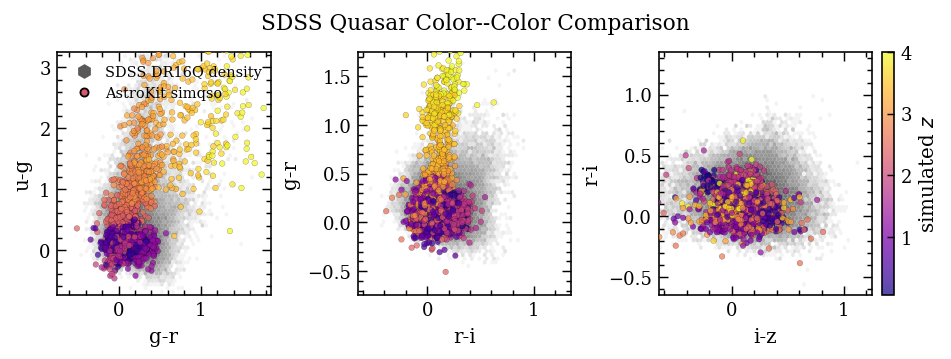

In [17]:
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

# ApJ-like styling: clean white background, inward ticks, thin axes, compact labels.
with plt.rc_context(
    {
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "font.family": "serif",
        "font.size": 10,
        "axes.linewidth": 0.9,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "legend.frameon": False,
    }
):
    color_planes = [
        ("g-r", "u-g", (-0.75, 1.85), (-0.75, 3.25)),
        ("r-i", "g-r", (-0.65, 1.35), (-0.75, 1.75)),
        ("i-z", "r-i", (-0.65, 1.25), (-0.65, 1.35)),
    ]

    fig, axes = plt.subplots(
        1, 3, figsize=(7.2, 2.65), sharex=False, sharey=False, 
        constrained_layout=True
    )

    for ax, (xcol, ycol, xlim, ylim) in zip(axes, color_planes):
        x_real = colors_real[xcol]
        y_real = colors_real[ycol]
        real_ok = (
            np.isfinite(x_real)
            & np.isfinite(y_real)
            & (x_real >= xlim[0])
            & (x_real <= xlim[1])
            & (y_real >= ylim[0])
            & (y_real <= ylim[1])
        )

        # DR16Q density as a subdued grayscale background.
        ax.hexbin(
            x_real[real_ok],
            y_real[real_ok],
            gridsize=58,
            extent=(*xlim, *ylim),
            mincnt=1,
            cmap="Greys",
            norm=LogNorm(),
            linewidths=0.0,
            alpha=0.78,
        )

        # Simulated quasars as smaller, outlined points so they remain visible over the density map.
        sc = ax.scatter(
            colors_sim[xcol],
            colors_sim[ycol],
            c=z_sim_plot,
            s=10,
            cmap="plasma",
            vmin=Z_MIN,
            vmax=Z_MAX,
            alpha=0.72,
            edgecolors="black",
            linewidths=0.12,
            rasterized=True,
            zorder=3,
        )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.minorticks_on()
        ax.tick_params(which="both", width=0.8)
        ax.tick_params(which="major", length=5)
        ax.tick_params(which="minor", length=2.5)

    cbar = fig.colorbar(sc, ax=axes, pad=0.012, fraction=0.035)
    cbar.set_label(r"simulated $z$")
    cbar.ax.tick_params(direction="in", length=4, width=0.8)

    legend_handles = [
        Line2D([0], [0], marker="h", color="0.35", linestyle="None", markersize=7, label="SDSS DR16Q density"),
        Line2D([0], [0], marker="o", color="black", markerfacecolor="#d8576b", linestyle="None", markersize=4.5, label="AstroKit simqso"),
    ]
    axes[0].legend(handles=legend_handles, loc="upper left", fontsize=8, handletextpad=0.45)

    fig.suptitle(r"SDSS Quasar Color--Color Comparison", fontsize=12)
    plt.show()

## 7. Quantitative Sanity Check

下面用每个颜色的一维分布做一个简单的 KS 检验，并列出中位数和 16-84 百分位范围。这个检验不是完整的选择函数校准，只用于快速检查模拟颜色是否落在真实类星体的合理范围内。

In [ ]:
rows = []
for color_name in ["u-g", "g-r", "r-i", "i-z"]:
    sim_values = colors_sim[color_name]
    real_values = colors_real[color_name]
    sim_values = sim_values[np.isfinite(sim_values)]
    real_values = real_values[np.isfinite(real_values)]
    ks = ks_2samp(sim_values, real_values)
    rows.append(
        {
            "color": color_name,
            "sim_median": np.median(sim_values),
            "sim_p16": np.percentile(sim_values, 16),
            "sim_p84": np.percentile(sim_values, 84),
            "dr16_median": np.median(real_values),
            "dr16_p16": np.percentile(real_values, 16),
            "dr16_p84": np.percentile(real_values, 84),
            "ks_stat": ks.statistic,
            "ks_pvalue": ks.pvalue,
        }
    )

summary = Table(rows)
for col in summary.colnames[1:]:
    summary[col].format = ".3g"
summary

color,sim_median,sim_p16,sim_p84,dr16_median,dr16_p16,dr16_p84,ks_stat,ks_pvalue
str3,float32,float32,float32,float64,float64,float64,float64,float64
u-g,0.32,-0.0136,2.07,0.326,0.0486,0.824,0.185,2.55e-54
g-r,0.166,-0.00852,0.606,0.18,0.0144,0.4,0.113,1.26e-20
r-i,0.0844,-0.0254,0.215,0.138,-0.0172,0.328,0.185,3.91e-54
i-z,0.0829,-0.0618,0.243,0.147,-0.0736,0.383,0.185,1.14e-54
